In [ ]:
import pandas as pd
pd.set_option('display.max_rows', 256)  # Set to the number of rows you want to see

# Overview results

In [1]:
from src.utils import get_grouped_dfs

In [18]:
import os
from pathlib import Path

root_dir=Path('/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/results')

dirs = [p for p in root_dir.iterdir() if p.is_dir()]


In [19]:
import json
configs = {}

for p in root_dir.iterdir():
    if p.is_dir():
        config_path = p / "config.json"
        if config_path.exists():
            with open(config_path, "r") as f:
                config = json.load(f)
                configs[config["model"]] = config["model_type"] 


## GIFT-Eval-ZS

In [118]:
def load_dfs(term_length, leakage_ds):
    results = get_grouped_dfs(root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/results', 
                            ds_properties='results/dataset_properties.csv',
                            leakage_ds=leakage_ds,
                            term_length=term_length)

    df = results["overall"].sort_values(by=["eval_metrics/mean_weighted_sum_quantile_loss"])
    df = df.rename(columns={"eval_metrics/mean_weighted_sum_quantile_loss": "Mean CRPS", "eval_metrics/MASE[0.5]": "MASE", "rank": "Rank (Mean CRPS)", "Rank_MASE": "Rank (MASE)"})
    df = df[["Mean CRPS", "Rank (Mean CRPS)", "MASE"]]

    df.insert(0, column="Model Type", value=df.index.map(configs))
    df["Model Type"] = df["Model Type"].replace("zero-shot", "pretrained")

    # release date after thesis start
    updated_models = ["Moirai2", "TimeCopilot", "TEMPO_ENSEMBLE", "TiRex", "TabPFN-TS", "sundial_base_128m", "Toto_Open_Base_1.0", "YingLong_300m", "YingLong_110m", "YingLong_50m", "YingLong_6m"]

    df["Published after 04/2025"] = df.reset_index(drop=False)["model"].apply(
        lambda x: "Yes" if x in updated_models else ("-" if "Chronos-Bolt" in x else "No")
    ).values

    df = df.reset_index()
    df.index += 1


    df = results["overall"].sort_values(by=["eval_metrics/mean_weighted_sum_quantile_loss"])
    df = df.rename(columns={"eval_metrics/mean_weighted_sum_quantile_loss": "Mean CRPS", "eval_metrics/MASE[0.5]": "MASE", "rank": "Rank (Mean CRPS)", "Rank_MASE": "Rank (MASE)"})
    df = df[["Mean CRPS", "Rank (Mean CRPS)", "MASE"]]

    df.insert(0, column="Model Type", value=df.index.map(configs))
    df["Model Type"] = df["Model Type"].replace("zero-shot", "pretrained")

    # release date after thesis start
    updated_models = ["Moirai2", "TimeCopilot", "TEMPO_ENSEMBLE", "TiRex", "TabPFN-TS", "sundial_base_128m", "Toto_Open_Base_1.0", "YingLong_300m", "YingLong_110m", "YingLong_50m", "YingLong_6m"]

    df["Published after 04/2025"] = df.reset_index(drop=False)["model"].apply(
        lambda x: "Yes" if x in updated_models else ("-" if "Chronos-Bolt" in x else "No")
    ).values

    df = df.reset_index()
    df.index += 1

    return df

def print_latex(df_out):
    def bold_if_chronos(s):
        s_esc = str(s)
        
        if "chronos-bolt" in s.lower():
            s_esc = s_esc.replace("FT_Full", r"FT\textsubscript{Full}")  # keep underscores safe
            s_esc = s_esc.replace("FT_LongOut", r"FT\textsubscript{LongOut}")  # keep underscores safe
            return rf"\textbf{{{s_esc}}}"

        else:
            s_esc = s.replace("_", r"\_")  # keep underscores safe
        return s_esc

    df_out = df_out.copy()
    df_out["model"] = df_out["model"].astype(str).map(bold_if_chronos)

    latex = df_out.to_latex(
        index=True,
        float_format="%.3f",
        label="tab:gift_eval",
        escape=False,  # allow \textbf{} through
    )
    print(latex)

In [119]:
df = load_dfs(term_length=["medium"], leakage_ds = ["electricity", "kdd_cup_2018", "solar"])

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


In [120]:
print_latex(df)

\begin{table}
\label{tab:gift_eval}
\begin{tabular}{lllrrrl}
\toprule
 & model & Model Type & Mean CRPS & Rank (Mean CRPS) & MASE & Published after 04/2025 \\
\midrule
1 & TEMPO\_ENSEMBLE & fine-tuned & 0.375 & 11.688 & 0.595 & Yes \\
2 & TimeCopilot & agentic & 0.481 & 8.375 & 0.758 & Yes \\
3 & Toto\_Open\_Base\_1.0 & pretrained & 0.484 & 9.688 & 0.749 & Yes \\
4 & TiRex & pretrained & 0.486 & 7.875 & 0.762 & Yes \\
5 & \textbf{Chronos-Bolt-mini-Ensemble} & fine-tuned & 0.487 & 9.188 & 0.745 & - \\
6 & \textbf{Chronos-Bolt-small-Ensemble} & fine-tuned & 0.489 & 9.000 & 0.762 & - \\
7 & \textbf{Chronos-Bolt-base-Ensemble} & fine-tuned & 0.489 & 9.875 & 0.748 & - \\
8 & \textbf{Chronos-Bolt-tiny-Ensemble} & fine-tuned & 0.491 & 10.625 & 0.767 & - \\
9 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+LinQC} & fine-tuned & 0.497 & 13.375 & 0.749 & - \\
10 & Moirai2 & pretrained & 0.502 & 15.000 & 0.733 & Yes \\
11 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+ConQC} & fine-tuned &

In [39]:
df = load_dfs(term_length=["medium"], leakage_ds = [])#)["electricity", "kdd_cup_2018", "solar"])

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


In [40]:
print_latex(df)

\begin{table}
\label{tab:gift_eval}
\begin{tabular}{lllrrrl}
\toprule
 & model & Model Type & Mean CRPS & Rank (Mean CRPS) & MASE & Published after 04/2025 \\
\midrule
1 & TEMPO\_ENSEMBLE & fine-tuned & 0.428 & 14.857 & 0.677 & Yes \\
2 & TiRex & pretrained & 0.486 & 7.190 & 0.760 & Yes \\
3 & TimeCopilot & agentic & 0.490 & 8.524 & 0.768 & Yes \\
4 & \textbf{Chronos-Bolt-base-Ensemble} & fine-tuned & 0.492 & 8.857 & 0.756 & - \\
5 & \textbf{Chronos-Bolt-mini-Ensemble} & fine-tuned & 0.494 & 8.619 & 0.761 & - \\
6 & \textbf{Chronos-Bolt-small-Ensemble} & fine-tuned & 0.497 & 9.190 & 0.775 & - \\
7 & Toto\_Open\_Base\_1.0 & pretrained & 0.499 & 10.857 & 0.772 & Yes \\
8 & \textbf{Chronos-Bolt-tiny-Ensemble} & fine-tuned & 0.499 & 10.333 & 0.782 & - \\
9 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+LinQC} & fine-tuned & 0.505 & 13.048 & 0.768 & - \\
10 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+ConQC} & fine-tuned & 0.516 & 14.333 & 0.768 & - \\
11 & Moirai2 & pretrained & 

In [9]:
import numpy as np 
df["percentage improvement vs tiny"] = (0.522730 - df["Mean CRPS"]) / 0.522730

In [89]:
import pandas as pd
pd.set_option('display.float_format', '{:.6f}'.format)

In [22]:
df

,model,Model Type,Mean CRPS,Rank (Mean CRPS),MASE,Published after 04/2025
1,TEMPO_ENSEMBLE,fine-tuned,0.363743,9.0625,0.642069,Yes
2,Chronos-Bolt-mini-Ensemble,fine-tuned,0.464682,8.3750,0.759778,-
3,Chronos-Bolt-small-Ensemble,fine-tuned,0.466997,9.2500,0.771999,-
4,Chronos-Bolt-tiny-Ensemble,fine-tuned,0.468030,10.5625,0.779123,-
5,Chronos-Bolt-base-Ensemble,fine-tuned,0.468820,9.3750,0.766378,-
6,Chronos-Bolt-tiny-FT_Full+LinQC,fine-tuned,0.483658,14.1875,0.776274,-
7,TimeCopilot,agentic,0.490466,9.5625,0.790515,Yes
8,Toto_Open_Base_1.0,pretrained,0.493871,9.1875,0.793404,Yes
9,Crossformer,deep-learning,0.494045,27.6875,1.288066,No
10,TiRex,pretrained,0.495201,10.2500,0.795700,Yes


In [ ]:
# report results on GIFT Eval
# report results on univariate and multivariate data in the appendix
# report results on gift eval zs. -> further investigate Solar 
# in chronos the solar data is used for pretraining -> 5 min (native), 1h hour (mean aggregation) 
# in gift eval solar is used from alabama aggregated on 10 Minutes and 1 H -> is there an overlap? we need to remove this as well
# why is crossformer only so good on this single dataset?

In [26]:
def bold_if_chronos(s):
    s = str(s)
    
    if "chronos-bolt" in s.lower():
        s = s.replace("FT_Full", r"FT\textsubscript{Full}")  # keep underscores safe
        s = s.replace("FT_LongOut", r"FT\textsubscript{LongOut}")  # keep underscores safe
        return rf"\textbf{{{s}}}"

    else:
        s = s.replace("_", r"\_")  # keep underscores safe
    return s

df_out = df.copy()
df_out["model"] = df_out["model"].astype(str).map(bold_if_chronos)
# 
latex = df_out.to_latex(
    index=True,
    float_format="%.3f",
    label="tab:gift_eval",
    escape=False,  # allow \textbf{} through
)
print(latex)

\begin{table}
\label{tab:gift_eval}
\begin{tabular}{lllrrrl}
\toprule
 & model & Model Type & Mean CRPS & Rank (Mean CRPS) & MASE & Published after 04/2025 \\
\midrule
1 & TEMPO\_ENSEMBLE & fine-tuned & 0.364 & 9.062 & 0.642 & Yes \\
2 & \textbf{Chronos-Bolt-mini-Ensemble} & fine-tuned & 0.465 & 8.375 & 0.760 & - \\
3 & \textbf{Chronos-Bolt-small-Ensemble} & fine-tuned & 0.467 & 9.250 & 0.772 & - \\
4 & \textbf{Chronos-Bolt-tiny-Ensemble} & fine-tuned & 0.468 & 10.562 & 0.779 & - \\
5 & \textbf{Chronos-Bolt-base-Ensemble} & fine-tuned & 0.469 & 9.375 & 0.766 & - \\
6 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+LinQC} & fine-tuned & 0.484 & 14.188 & 0.776 & - \\
7 & TimeCopilot & agentic & 0.490 & 9.562 & 0.791 & Yes \\
8 & Toto\_Open\_Base\_1.0 & pretrained & 0.494 & 9.188 & 0.793 & Yes \\
9 & Crossformer & deep-learning & 0.494 & 27.688 & 1.288 & No \\
10 & TiRex & pretrained & 0.495 & 10.250 & 0.796 & Yes \\
11 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}+ConQC} & fine-t

In [83]:
def bold_if_chronos(s):
    s = str(s)
    
    if "chronos-bolt" in s.lower():
        s_esc = s.replace("PP_Offset", r"PP\textsubscript{Offset}")  # keep underscores safe
        s_esc = s_esc.replace("PP_QuantReg", r"PP\textsubscript{QuantReg}")  # keep underscores safe
        s_esc = s_esc.replace("FT_Full", r"FT\textsubscript{Full}")  # keep underscores safe
        s_esc = s_esc.replace("FT_LongOut", r"FT\textsubscript{LongOut}")  # keep underscores safe
        return rf"\textbf{{{s_esc}}}"

    else:
        s_esc = s.replace("_", r"\_")  # keep underscores safe
    return s_esc

df_out = df.copy()
df_out["model"] = df_out["model"].astype(str).map(bold_if_chronos)

latex = df_out.to_latex(
    index=True,
    float_format="%.3f",
    label="tab:gift_eval",
    escape=False,  # allow \textbf{} through
)
print(latex)

\begin{table}
\label{tab:gift_eval}
\begin{tabular}{lllrrrl}
\toprule
 & model & Model Type & Mean CRPS & Rank (Mean CRPS) & MASE & Published after 04/2025 \\
\midrule
1 & TEMPO\_ENSEMBLE & fine-tuned & 0.375 & 11.688 & 0.595 & Yes \\
2 & TimeCopilot & agentic & 0.481 & 8.375 & 0.758 & Yes \\
3 & Toto\_Open\_Base\_1.0 & pretrained & 0.484 & 9.688 & 0.749 & Yes \\
4 & TiRex & pretrained & 0.486 & 7.875 & 0.762 & Yes \\
5 & \textbf{Chronos-Bolt-mini-Ensemble} & fine-tuned & 0.487 & 9.188 & 0.745 & - \\
6 & \textbf{Chronos-Bolt-small-Ensemble} & fine-tuned & 0.489 & 9.000 & 0.762 & - \\
7 & \textbf{Chronos-Bolt-base-Ensemble} & fine-tuned & 0.489 & 9.875 & 0.748 & - \\
8 & \textbf{Chronos-Bolt-tiny-Ensemble} & fine-tuned & 0.491 & 10.625 & 0.767 & - \\
9 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}-PP\textsubscript{QuantReg}} & fine-tuned & 0.497 & 13.375 & 0.749 & - \\
10 & Moirai2 & pretrained & 0.502 & 15.000 & 0.733 & Yes \\
11 & \textbf{Chronos-Bolt-tiny-FT\textsubscript{Full}-

In [ ]:
results["univariate"].sort_values(by=["univariate", "eval_metrics/mean_weighted_sum_quantile_loss"])

eval_metrics/MASE[0.5]   
univariate model                                                           
False      TEMPO_ENSEMBLE                                       0.593054  \
           Chronos-Bolt-mini-Ensemble                           0.792758   
           Chronos-Bolt-small-Ensemble                          0.809109   
           Chronos-Bolt-tiny-Ensemble                           0.816947   
           Chronos-Bolt-base-Ensemble                           0.797030   
           Chronos-Bolt-tiny-FT_Full-PP_QuantReg                0.798806   
           Chronos-Bolt-tiny-FT_Full-PP_Offset                  0.781803   
           Toto_Open_Base_1.0                                   0.823608   
           TiRex                                                0.830002   
           TimeCopilot                                          0.842816   
           Moirai2                                              0.791540   
           Chronos-Bolt-tiny-FT_LongOut                         0.879844   
           Chronos-Bolt-tiny-FT_Full                            0.791288   
           sundial_base_128m                                    0.825087   
           YingLong_300m                                        0.916967   
           PatchTST                                             0.919565   
           YingLong_110m                                        0.901017   
           YingLong_50m                                         0.926867   
           TabPFN-TS                                            0.869468   
           iTransformer                                         0.928616   
           TFT                                                  1.089376   
           YingLong_6m                                          0.989451   
           timesfm_2_0_500m                                     0.869759   
           TTM-R2-Finetuned                                     0.875216   
           Chronos-Bolt-tiny-PP_QuantReg                        1.091385   
           Moirai_small                                         1.091661   
           chronos_bolt_base                                    1.028188   
           Chronos-Bolt-tiny-PP_Offset                          1.101843   
           chronos_bolt_small                                   1.051904   
           VisionTS                                             0.870695   
           Moirai_large                                         1.126837   
           Moirai_base                                          1.192648   
           TIDE                                                 1.129982   
           Crossformer                                          1.290918   
           Lag-Llama                                            1.201942   
           N-BEATS                                              1.033284   
           Chronos_large                                        1.165464   
           Chronos_small                                        1.183520   
           Chronos_base                                         1.176954   
           TimesFM                                              2.181762   
           DLinear                                              1.216270   
           TTM-R2-Pretrained                                    1.157971   
           Timer                                                1.218467   
           DeepAR                                               1.954598   
           TTM-R1-Pretrained                                    1.379980   
           Seasonal_Naive                                       1.000000   
           Auto_Arima                                           1.566806   
           Auto_Theta                                           1.123030   
           Naive                                                1.283279   
           Auto_ETS                                             1.613219   
True       Crossformer                                          2.366370   
           TiRex      

In [ ]:
print(df.to_latex(index=True,                # include model names (default True)
                  float_format="%.3f",       # format numbers to 3 decimals
                  # caption="Full CRPS Results",    # optional caption
                  label="tab:gift_eval",          # optional label for referencing
                  escape=True               # keep underscores in names
                  ))

\begin{table}
\label{tab:gift_eval}
\begin{tabular}{lrrr}
\toprule
 & Mean CRPS & MASE[0.5] & Rank (CRPS) \\
model &  &  &  \\
\midrule
Crossformer & 0.422 & 1.475 & 23.900 \\
TEMPO\_ensemble & 0.472 & 0.767 & 15.425 \\
Chronos-Bolt-mini-Ensemble & 0.474 & 0.766 & 7.550 \\
Chronos-Bolt-small-Ensemble & 0.475 & 0.777 & 8.000 \\
Chronos-Bolt-base-Ensemble & 0.476 & 0.764 & 8.098 \\
TiRex & 0.477 & 0.771 & 7.225 \\
Chronos-Bolt-tiny-Ensemble & 0.480 & 0.788 & 9.375 \\
Chronos-Bolt-tiny-FT\_Full-PP\_QuantReg & 0.488 & 0.777 & 11.775 \\
Toto\_Open\_Base\_1.0 & 0.491 & 0.790 & 9.500 \\
Chronos-Bolt-tiny-FT\_Full-PP\_Offset & 0.502 & 0.777 & 13.525 \\
sundial\_base\_128m & 0.512 & 0.777 & 16.175 \\
Chronos-Bolt-tiny-FT\_LongOut & 0.512 & 0.846 & 15.400 \\
YingLong\_300m & 0.525 & 0.856 & 14.225 \\
Chronos-Bolt-tiny-FT\_Full & 0.527 & 0.781 & 18.525 \\
PatchTST & 0.529 & 0.870 & 17.900 \\
TabPFN-TS & 0.533 & 0.841 & 18.525 \\
YingLong\_110m & 0.541 & 0.871 & 16.625 \\
TFT & 0.542 & 0.959 & 18.

# Calibration experiments

In [41]:
import matplotlib.pyplot as plt
import re

In [70]:
import seaborn as sns

def plot_calibration_samples(results, save_path = None):
    overall = results["overall"].sort_values(by=["eval_metrics/mean_weighted_sum_quantile_loss"])

    # Common prefix
    m = "Chronos-Bolt-tiny"

    sample_sizes = [5, 10, 20, 30, 50, 100, 200, 500]


    # Build sub_dfs
    sub_qreg = overall.loc[[f"{m}+LinQC_{n}" for n in sample_sizes]].copy()
    sub_offset = overall.loc[[f"{m}+ConQC_{n}" for n in sample_sizes]].copy()


    # Extract numeric values for x-axis
    sub_qreg["x_val"] = sub_qreg.index.to_series().apply(lambda x: int(re.search(r"\d+$", x).group()))
    sub_offset["x_val"] = sub_offset.index.to_series().apply(lambda x: int(re.search(r"\d+$", x).group()))

    # Get reference value for Chronos-Bolt-tiny
    ref_val = overall.loc["Chronos-Bolt-tiny", "eval_metrics/mean_weighted_sum_quantile_loss"]

    # Get colors from seaborn deep palette
    palette = sns.color_palette("deep")

    # Assign colors
    color_qreg = palette[0]   # first color (usually blue)
    color_offset = palette[1] # second color (usually orange)

    # Convert to string categories
    sub_qreg["x_cat"] = sub_qreg["x_val"].astype(str)
    sub_offset["x_cat"] = sub_offset["x_val"].astype(str)

    fig, ax = plt.subplots(figsize=(12,7))

    ax.axhline(ref_val, linestyle="--", linewidth=4, 
            label="C-Bolt-tiny", color="black")

    ax.plot(sub_offset["x_cat"], sub_offset["eval_metrics/mean_weighted_sum_quantile_loss"], 
            marker="s", label="C-Bolt-tiny+ConQC", 
            linewidth=4, markersize=9, color=color_offset)

    ax.plot(sub_qreg["x_cat"], sub_qreg["eval_metrics/mean_weighted_sum_quantile_loss"], 
            marker="s", label="C-Bolt-tiny+LinQC", 
            linewidth=4, markersize=9, color=color_qreg)

    ax.set_xlabel("Max Calibration Samples M", fontsize=20, labelpad=10)
    ax.set_ylabel("Mean relative CRPS", fontsize=20, labelpad=10)
    ax.grid(True, linestyle="--", alpha=0.8)
    ax.tick_params(axis='both', which='major', labelsize=18)
    ax.legend(frameon=False, fontsize=18)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()


/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


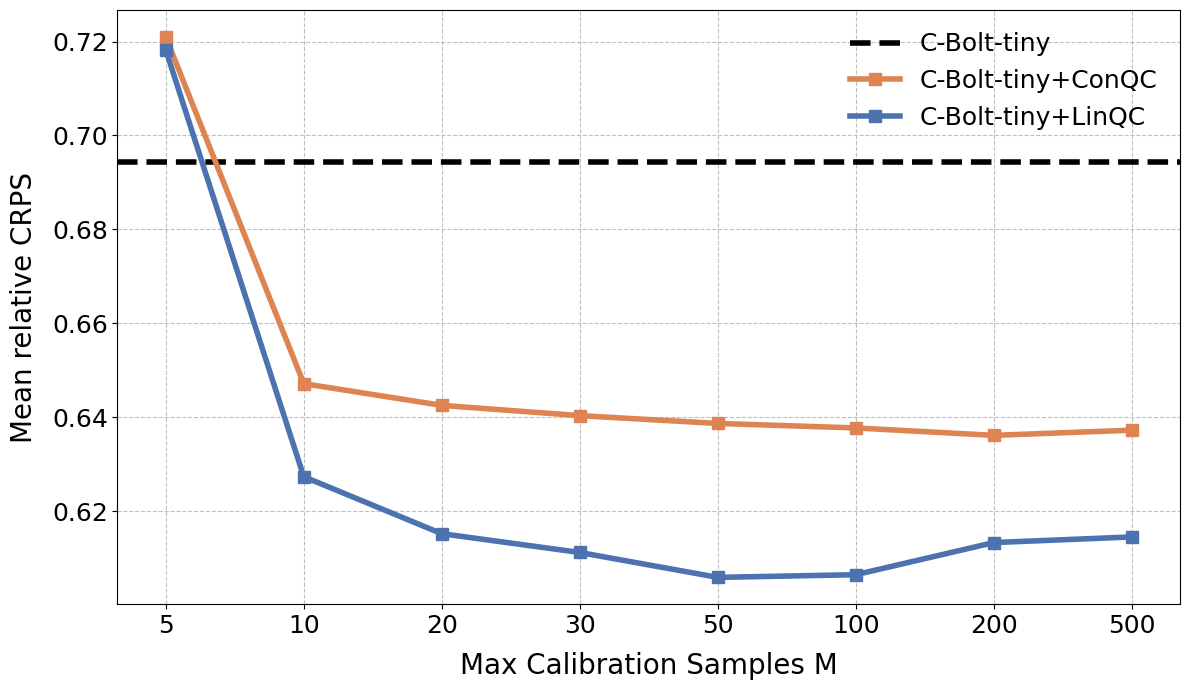

In [73]:
from src.utils import get_grouped_dfs
results = get_grouped_dfs(root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size', 
                          ds_properties='results/dataset_properties.csv',
                          term_length=["long"],
                          )
plot_calibration_samples(results, "../figures/GIFT_EVAL_ZS_long_calibration_samples.png")

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


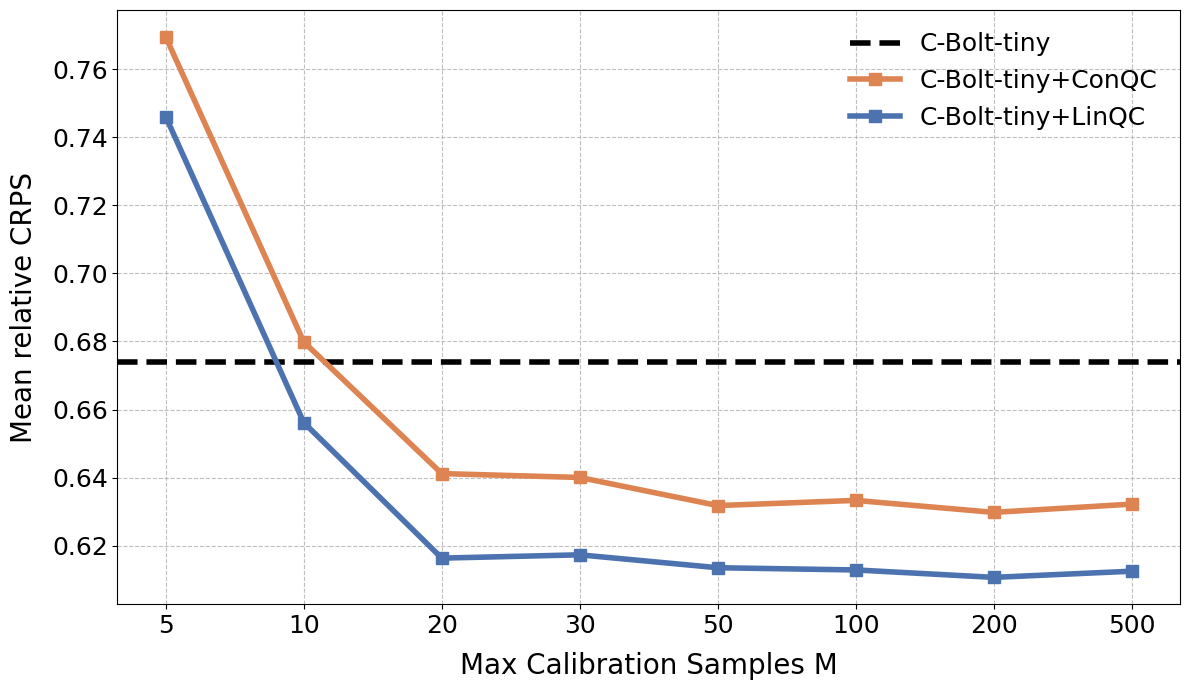

In [74]:
from src.utils import get_grouped_dfs
results = get_grouped_dfs(root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size', 
                          ds_properties='results/dataset_properties.csv',
                          term_length=["medium"],
                          )
plot_calibration_samples(results, "../figures/GIFT_EVAL_ZS_medium_calibration_samples.png")

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


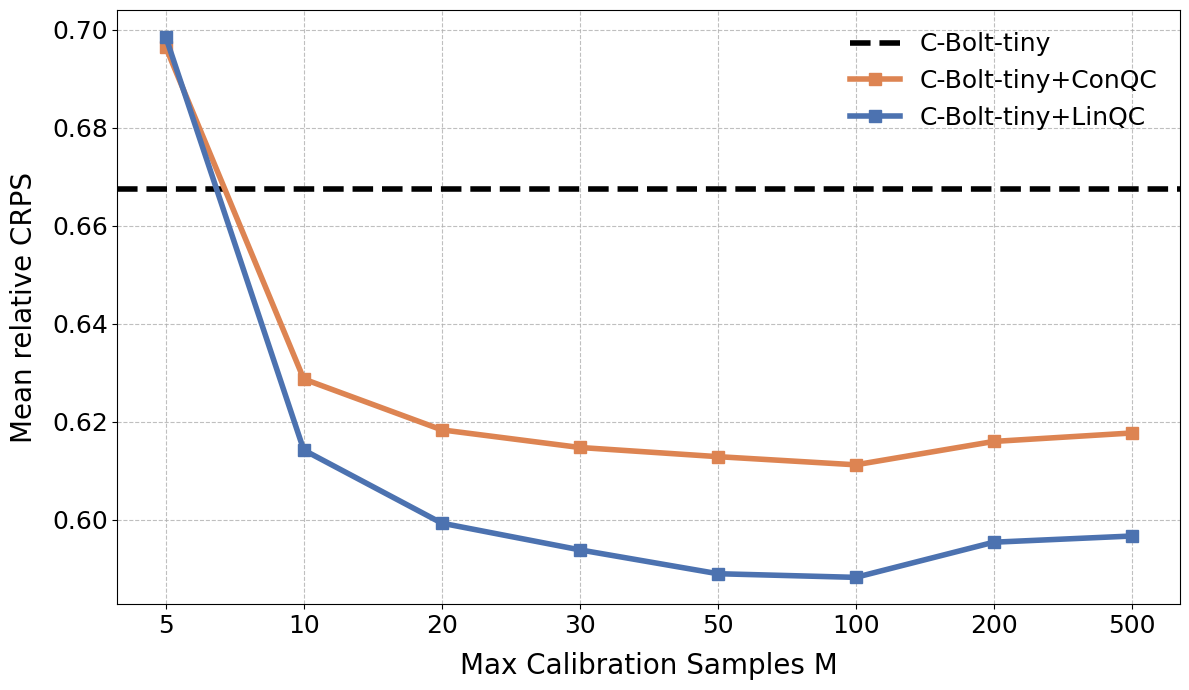

In [75]:
from src.utils import get_grouped_dfs
results = get_grouped_dfs(root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size', 
                          ds_properties='results/dataset_properties.csv',
                          term_length=["long"],
                          leakage_ds=[]
                          )
plot_calibration_samples(results, "../figures/GIFT_EVAL_long_calibration_samples.png")

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


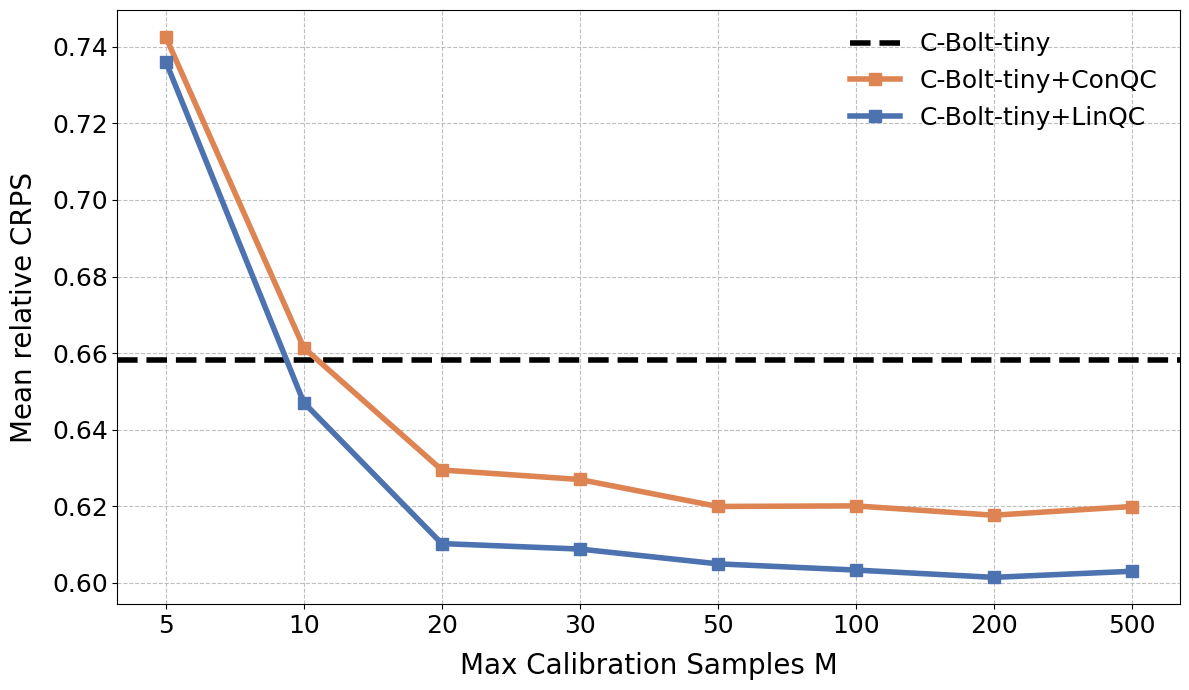

In [76]:
from src.utils import get_grouped_dfs
results = get_grouped_dfs(root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size', 
                          ds_properties='results/dataset_properties.csv',
                          term_length=["medium"],
                          leakage_ds=[]
                          )
plot_calibration_samples(results, "../figures/GIFT_EVAL_medium_calibration_samples.png")

In [110]:
import os, re
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

def _plot_calib_panel(ax, results, title, m="Chronos-Bolt-tiny"):
    overall = results["overall"].sort_values(by=["eval_metrics/mean_weighted_sum_quantile_loss"])

    sample_sizes = [5, 10, 20, 30, 50, 100, 200, 500]

    # Build sub_dfs
    sub_qreg = overall.loc[[f"{m}+LinQC_{n}" for n in sample_sizes]].copy()
    sub_offset = overall.loc[[f"{m}+ConQC_{n}" for n in sample_sizes]].copy()

    # Extract numeric values for x-axis
    sub_qreg["x_val"] = sub_qreg.index.to_series().apply(lambda x: int(re.search(r"\d+$", x).group()))
    sub_offset["x_val"] = sub_offset.index.to_series().apply(lambda x: int(re.search(r"\d+$", x).group()))

    # Reference value
    ref_val = overall.loc[m, "eval_metrics/mean_weighted_sum_quantile_loss"]

    # Colors
    palette = sns.color_palette("deep")
    color_qreg   = palette[0]
    color_offset = palette[1]

    # Convert to string categories for nicer ticks
    sub_qreg["x_cat"] = sub_qreg["x_val"].astype(str)
    sub_offset["x_cat"] = sub_offset["x_val"].astype(str)

    # Plot
    ax.axhline(ref_val, linestyle="--", linewidth=4, label="Uncalibrated", color="black")
    ax.plot(sub_offset["x_cat"], sub_offset["eval_metrics/mean_weighted_sum_quantile_loss"],
            marker="s", label="+ConQC", linewidth=4, markersize=9, color=color_offset)
    ax.plot(sub_qreg["x_cat"], sub_qreg["eval_metrics/mean_weighted_sum_quantile_loss"],
            marker="s", label="+LinQC", linewidth=4, markersize=9, color=color_qreg)

    ax.set_title(f"{m} ({title})", fontsize=20, pad=12)
    ax.set_xlabel("Max Calibration Samples [M]", fontsize=18, labelpad=10)
    ax.grid(True, linestyle="--", alpha=0.8)
    ax.tick_params(axis='both', which='major', labelsize=14)

def plot_calibration_samples_two_panel(results_long, results_medium, save_path=None):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    _plot_calib_panel(axes[1], results_long, title="Long-term")
    _plot_calib_panel(axes[0], results_medium, title="Medium-term")

    # Single shared y-label
    fig.text(0.04, 0.5, "Mean relative CRPS", va="center", rotation="vertical", fontsize=18)

    # One legend for the whole figure (grab handles from the second axis)
    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False, fontsize=18, bbox_to_anchor=(0.5, -0.02))

    plt.tight_layout(rect=[0.06, 0.08, 1, 1])  # leave room for shared y and legend
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')
/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


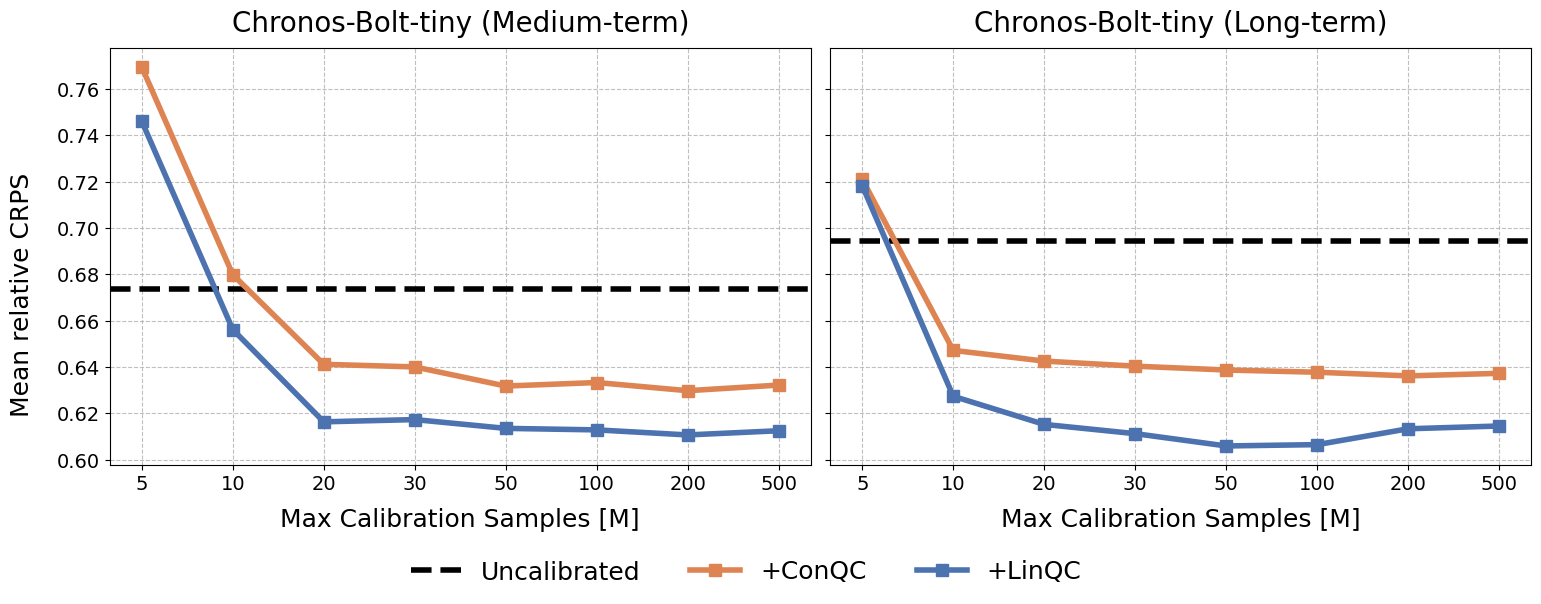

In [111]:
from src.utils import get_grouped_dfs

results_long = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["long"],
)

results_medium = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["medium"],
)

plot_calibration_samples_two_panel(
    results_long, results_medium,
    save_path="../figures/GIFT_EVAL_ZS_medium_long_calibration_samples.png"
)

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')
/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


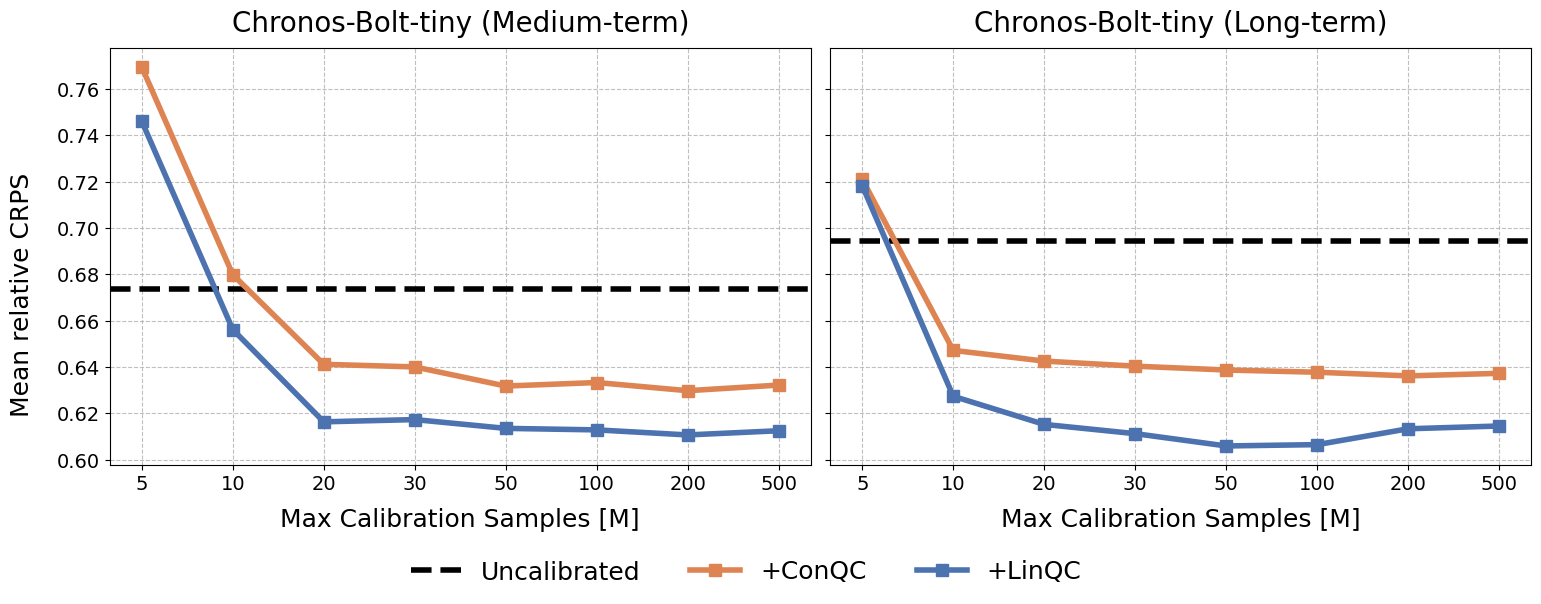

In [112]:
from src.utils import get_grouped_dfs

results_long = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["long"],
)

results_medium = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["medium"],
)

plot_calibration_samples_two_panel(
    results_long, results_medium,
    save_path="../figures/GIFT_EVAL_ZS_medium_long_calibration_samples.png"
)

/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')
/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/src/utils.py:198: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  dataset_properties_dict = dataset_properties.set_index('dataset').T.to_dict('dict')


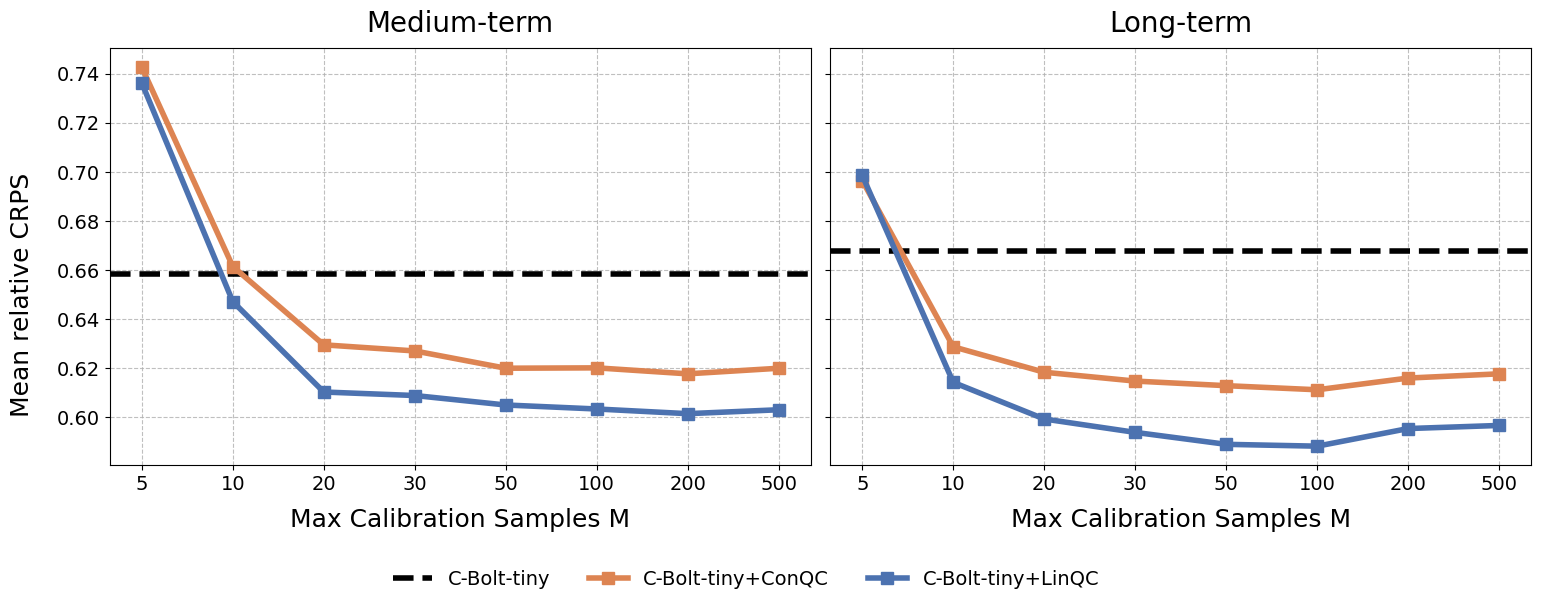

In [104]:
from src.utils import get_grouped_dfs

results_long = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["long"],
    leakage_ds = [],
)

results_medium = get_grouped_dfs(
    root_dir='/Users/louisskowronek/Documents/thesis/master-thesis/GIFT-Eval/experiments_calibration_size',
    ds_properties='results/dataset_properties.csv',
    term_length=["medium"],
    leakage_ds = [],
)

plot_calibration_samples_two_panel(
    results_long, results_medium,
    save_path="../figures/GIFT_EVAL_medium_long_calibration_samples.png"
)

In [ ]:
#why does 40 work so well?
# - hire band 6a L4 -> 100 k
# - highest band in 6a